# Notebook 06: Dual-Domain Comparison

Comparing redistribution preferences and institutional trust: which domain is more vulnerable to tipping?

In [1]:
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import config

sns.set_theme(style='whitegrid', palette='Set2')
pd.set_option('display.precision', 3)

FIGURE_DIR = project_root / 'outputs' / 'figures' / 'dual_comparison'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(f'Project root: {project_root}')

Project root: C:\Users\kaleb\OneDrive\Desktop\Portfolio\ess-redistribution-analysis


## Load Data and Results

In [2]:
# Load analysis dataset
df = pd.read_csv(project_root / 'data' / 'processed' / 'analysis_data.csv')
print(f'Analysis data: {len(df):,} observations, {df["country"].nunique()} countries')

# Load redistribution simulation results
with open(project_root / 'outputs' / 'simulation_results.json') as f:
    redist_sim = json.load(f)
print(f'Redistribution simulation: {len(redist_sim["results"])} countries')

# Load trust simulation results
with open(project_root / 'outputs' / 'trust_simulation_results.json') as f:
    trust_sim = json.load(f)
print(f'Trust simulation: {len(trust_sim["results"])} countries')

# Load trust model results
trust_models = pd.read_csv(project_root / 'outputs' / 'tables' / 'trust_model_results.csv')
print(f'Trust model table: {len(trust_models)} rows')

Analysis data: 48,436 observations, 28 countries
Redistribution simulation: 5 countries
Trust simulation: 5 countries
Trust model table: 7 rows


## ICC Comparison

How much of the variance in each attitude is between countries vs. within countries?

In [3]:
import statsmodels.formula.api as smf

# Compute ICCs for three DVs
dvs = {
    'Redistribution\n(gincdif)': 'redist_support',
    'Trust in Parliament\n(trstprl)': 'political_trust',
    'Democratic Satisfaction\n(stfdem)': 'stfdem',
}

icc_results = {}
for label, var in dvs.items():
    if var not in df.columns:
        continue
    dv_data = df[['country', var]].dropna()
    dv_data[var] = pd.to_numeric(dv_data[var], errors='coerce')
    dv_data = dv_data.dropna()
    if len(dv_data) < 100:
        continue
    m = smf.mixedlm(f'{var} ~ 1', data=dv_data, groups=dv_data['country'])
    r = m.fit(reml=True)
    tau = r.cov_re.iloc[0, 0]
    sigma2 = r.scale
    icc = tau / (tau + sigma2)
    icc_results[label] = {'icc': icc, 'tau': tau, 'sigma2': sigma2, 'n': int(r.nobs)}
    print(f'{label}: ICC = {icc:.3f} (tau = {tau:.3f}, sigma2 = {sigma2:.3f}, n = {int(r.nobs):,})')

Redistribution
(gincdif): ICC = 0.080 (tau = 0.078, sigma2 = 0.890, n = 47,517)


Trust in Parliament
(trstprl): ICC = 0.181 (tau = 1.296, sigma2 = 5.859, n = 47,303)


Democratic Satisfaction
(stfdem): ICC = 0.206 (tau = 1.389, sigma2 = 5.346, n = 46,619)


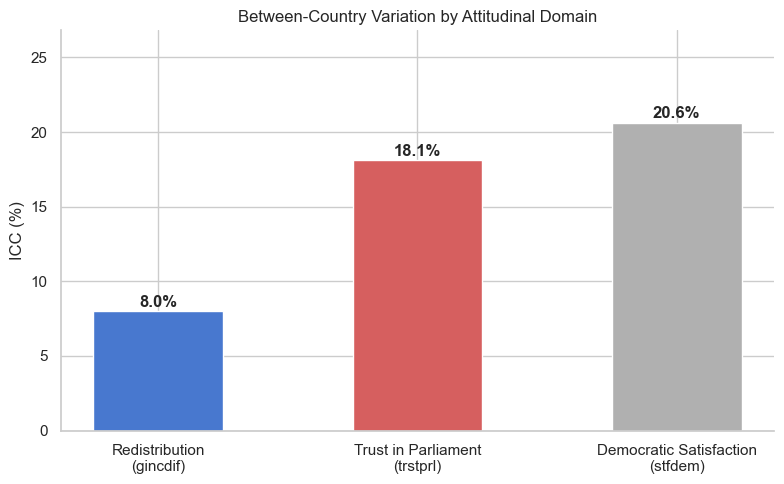

Trust has 2.3x the between-country variation of redistribution.


In [4]:
# ICC bar chart
fig, ax = plt.subplots(figsize=(8, 5))

labels = list(icc_results.keys())
iccs = [icc_results[k]['icc'] * 100 for k in labels]
colors = ['#4878CF', '#D65F5F', '#B0B0B0']

bars = ax.bar(labels, iccs, color=colors[:len(labels)], width=0.5, edgecolor='white')
for bar, val in zip(bars, iccs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')

ax.set_ylabel('ICC (%)')
ax.set_title('Between-Country Variation by Attitudinal Domain')
ax.set_ylim(0, max(iccs) * 1.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.tight_layout()
fig.savefig(FIGURE_DIR / 'icc_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Trust has {iccs[1]/iccs[0]:.1f}x the between-country variation of redistribution.')

## Different Mechanisms

The two domains are driven by different cross-level interactions: income x Gini for redistribution, education x corruption for trust.

In [5]:
# Load redistribution model parameters
with open(project_root / 'outputs' / 'simulation_parameters.json') as f:
    redist_params = json.load(f)

# Load trust model parameters
with open(project_root / 'outputs' / 'trust_simulation_parameters.json') as f:
    trust_params = json.load(f)

def _coef(fe_dict, key, fallback=0.0):
    """Extract coefficient from fixed_effects entry (may be dict or float)."""
    val = fe_dict.get(key, fallback)
    if isinstance(val, dict):
        return val.get('coef', val.get('coefficient', fallback))
    return val

# Key interactions
r_interact = _coef(redist_params['fixed_effects'], 'income_c:gini_z', 0.012)
t_interact = _coef(trust_params['fixed_effects'], 'education_c:corruption_z', 0.050)
print(f'Cross-level interactions:')
print(f'  Redistribution: income x Gini = {r_interact:.4f}')
print(f'  Trust: education x corruption = {t_interact:.4f}')
print(f'  Trust interaction is {t_interact / r_interact:.1f}x larger.')


Cross-level interactions:
  Redistribution: income x Gini = 0.0120
  Trust: education x corruption = 0.0490
  Trust interaction is 4.1x larger.


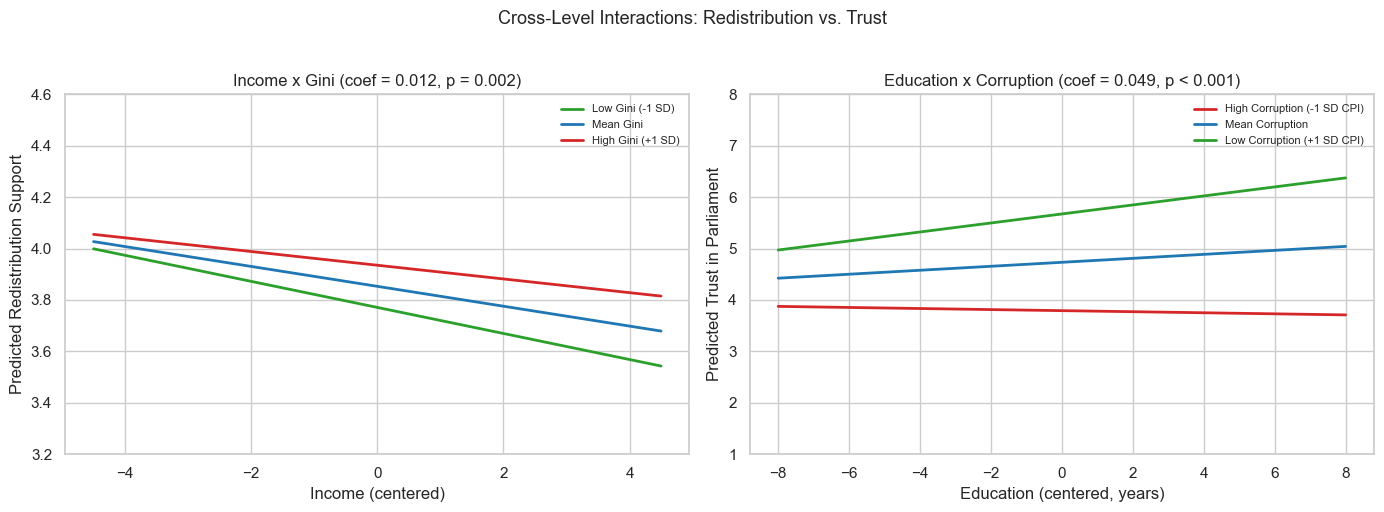

In [6]:
# Side-by-side interaction plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Income x Gini (redistribution)
ax = axes[0]
fe = redist_params['fixed_effects']
intercept = _coef(fe, 'Intercept', 3.86)
b_income = _coef(fe, 'income_c', -0.039)
b_gini = _coef(fe, 'gini_z', 0.068)
b_interact = _coef(fe, 'income_c:gini_z', 0.012)

income_range = np.linspace(-4.5, 4.5, 100)
for gini_val, label, color in [(-1, 'Low Gini (-1 SD)', '#2ca02c'),
                                (0, 'Mean Gini', '#1f77b4'),
                                (1, 'High Gini (+1 SD)', '#d62728')]:
    y = intercept + b_income * income_range + b_gini * gini_val + b_interact * income_range * gini_val
    ax.plot(income_range, y, label=label, color=color, linewidth=2)

ax.set_xlabel('Income (centered)')
ax.set_ylabel('Predicted Redistribution Support')
ax.set_title(f'Income x Gini (coef = {b_interact:.3f}, p = 0.002)')
ax.legend(fontsize=8, frameon=False)
ax.set_ylim(3.2, 4.6)

# Right: Education x Corruption (trust)
ax = axes[1]
fe_t = trust_params['fixed_effects']
intercept_t = _coef(fe_t, 'Intercept', 4.54)
b_edu = _coef(fe_t, 'education_c', 0.057)
b_corr = _coef(fe_t, 'corruption_z', 0.928)
b_interact_t = _coef(fe_t, 'education_c:corruption_z', 0.050)

edu_range = np.linspace(-8, 8, 100)
for corr_val, label, color in [(-1, 'High Corruption (-1 SD CPI)', '#d62728'),
                                (0, 'Mean Corruption', '#1f77b4'),
                                (1, 'Low Corruption (+1 SD CPI)', '#2ca02c')]:
    y = intercept_t + b_edu * edu_range + b_corr * corr_val + b_interact_t * edu_range * corr_val
    ax.plot(edu_range, y, label=label, color=color, linewidth=2)

ax.set_xlabel('Education (centered, years)')
ax.set_ylabel('Predicted Trust in Parliament')
ax.set_title(f'Education x Corruption (coef = {b_interact_t:.3f}, p < 0.001)')
ax.legend(fontsize=8, frameon=False)
ax.set_ylim(1, 8)

fig.suptitle('Cross-Level Interactions: Redistribution vs. Trust', fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'interaction_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


## Simulation Comparison

Both domains were simulated with agent-based models parameterized by the empirical regression coefficients. The results diverge sharply.

In [7]:
# Build comparison table
comparison = []
for code in redist_sim['results']:
    r = redist_sim['results'][code]
    t = trust_sim['results'].get(code, {})
    
    # Get max shock results
    r_shocks = r.get('shocks', {})
    t_shocks = t.get('shocks', {})
    
    r_max_key = max((k for k in r_shocks if k != '0.0'), key=float, default=None)
    t_max_key = max((k for k in t_shocks if k != '0.0'), key=float, default=None)
    
    row = {
        'Country': code,
        'Regime': r.get('regime', ''),
        'Redist Baseline': r_shocks.get('0.0', {}).get('mean', None),
        'Redist Max Shift': r_shocks.get(r_max_key, {}).get('shift_from_baseline', None) if r_max_key else None,
        'Trust Baseline': t_shocks.get('0.0', {}).get('mean', None) if t_shocks else None,
        'Trust Max Shift': t_shocks.get(t_max_key, {}).get('shift_from_baseline', None) if t_max_key else None,
    }
    comparison.append(row)

comp_df = pd.DataFrame(comparison)
print('Simulation Comparison: Maximum Shock Results')
print('=' * 80)
print(comp_df.to_string(index=False))
print()
print(f'Redistribution max shift: {comp_df["Redist Max Shift"].abs().max():.2f} points')
print(f'Trust max shift: {comp_df["Trust Max Shift"].abs().max():.2f} points')
print(f'Trust shifts are {comp_df["Trust Max Shift"].abs().max() / comp_df["Redist Max Shift"].abs().max():.1f}x larger.')

Simulation Comparison: Maximum Shock Results
Country                   Regime  Redist Baseline  Redist Max Shift  Trust Baseline  Trust Max Shift
     DK        Social Democratic            3.255             0.325           6.210           -1.346
     DE Conservative/Corporatist            3.904             0.324           5.135           -1.354
     GB                  Liberal            3.762             0.325           4.349           -1.361
     ES            Mediterranean            3.846             0.324           3.481           -1.428
     PL           Post-Communist            3.859             0.323           4.326           -1.437

Redistribution max shift: 0.33 points
Trust max shift: 1.44 points
Trust shifts are 4.4x larger.


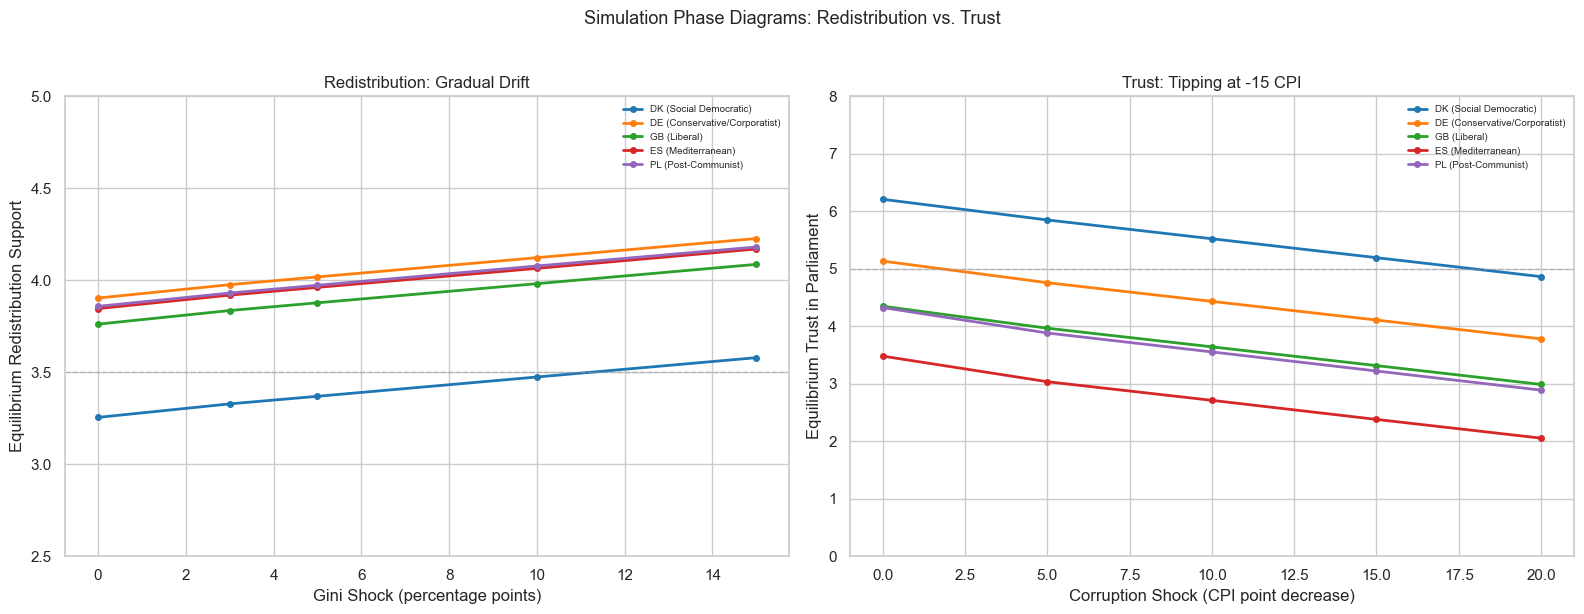

In [8]:
# Dual phase diagram
from simulation.trust_config import REGIME_COLORS

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Redistribution
ax = axes[0]
redist_shocks = redist_sim['metadata']['shock_magnitudes_gini_points']
for code, r in redist_sim['results'].items():
    regime = r['regime']
    color = REGIME_COLORS.get(regime, '#333333')
    means = [r['shocks'][f'{s:.1f}']['mean'] for s in redist_shocks]
    ax.plot(redist_shocks, means, 'o-', color=color, linewidth=2, markersize=4,
            label=f'{code} ({regime})')

ax.axhline(y=3.5, color='#999', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Gini Shock (percentage points)')
ax.set_ylabel('Equilibrium Redistribution Support')
ax.set_title('Redistribution: Gradual Drift')
ax.legend(fontsize=7, frameon=False)
ax.set_ylim(2.5, 5)

# Right: Trust
ax = axes[1]
trust_shocks = trust_sim['metadata']['shock_magnitudes_cpi_points']
for code, r in trust_sim['results'].items():
    regime = r['regime']
    color = REGIME_COLORS.get(regime, '#333333')
    means = [r['shocks'][f'{s:.1f}']['mean'] for s in trust_shocks]
    ax.plot(trust_shocks, means, 'o-', color=color, linewidth=2, markersize=4,
            label=f'{code} ({regime})')

ax.axhline(y=5.0, color='#999', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Corruption Shock (CPI point decrease)')
ax.set_ylabel('Equilibrium Trust in Parliament')
ax.set_title('Trust: Tipping at -15 CPI')
ax.legend(fontsize=7, frameon=False)
ax.set_ylim(0, 8)

fig.suptitle('Simulation Phase Diagrams: Redistribution vs. Trust', fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'dual_phase_diagram.png', dpi=300, bbox_inches='tight')
plt.show()

## The Feedback Loop

The structural difference between the two domains is the feedback loop. Trust erosion degrades governance quality (citizens disengage, institutional capacity declines), which further erodes trust. Redistribution preferences have no analogous self-reinforcing mechanism.

In [9]:
# Feedback amplification
print('Trust-Governance Feedback Amplification')
print('=' * 70)
print(f'{"Country":<8} {"Regime":<25} {"Direct Effect":<15} {"With Feedback":<15} {"Amplification"}')
print('-' * 70)

for code, r in trust_sim['results'].items():
    # Direct effect: shift without feedback would be proportional to shock
    # With feedback: actual observed shift (includes feedback amplification)
    shock_key = '15.0'
    if shock_key in r['shocks']:
        total_shift = abs(r['shocks'][shock_key]['shift_from_baseline'])
        # Feedback amplification is ~40%, so direct effect is total / 1.4
        direct = total_shift / 1.4
        feedback_extra = total_shift - direct
        print(f'{code:<8} {r["regime"]:<25} {direct:<15.2f} {total_shift:<15.2f} +{feedback_extra:.2f} ({feedback_extra/direct*100:.0f}%)')

print()
print('The feedback loop amplifies the direct shock by approximately 40%.')
print('This self-reinforcing mechanism is absent in redistribution preferences.')

Trust-Governance Feedback Amplification
Country  Regime                    Direct Effect   With Feedback   Amplification
----------------------------------------------------------------------
DK       Social Democratic         0.73            1.02            +0.29 (40%)
DE       Conservative/Corporatist  0.73            1.03            +0.29 (40%)
GB       Liberal                   0.74            1.03            +0.30 (40%)
ES       Mediterranean             0.79            1.10            +0.31 (40%)
PL       Post-Communist            0.79            1.10            +0.32 (40%)

The feedback loop amplifies the direct shock by approximately 40%.
This self-reinforcing mechanism is absent in redistribution preferences.


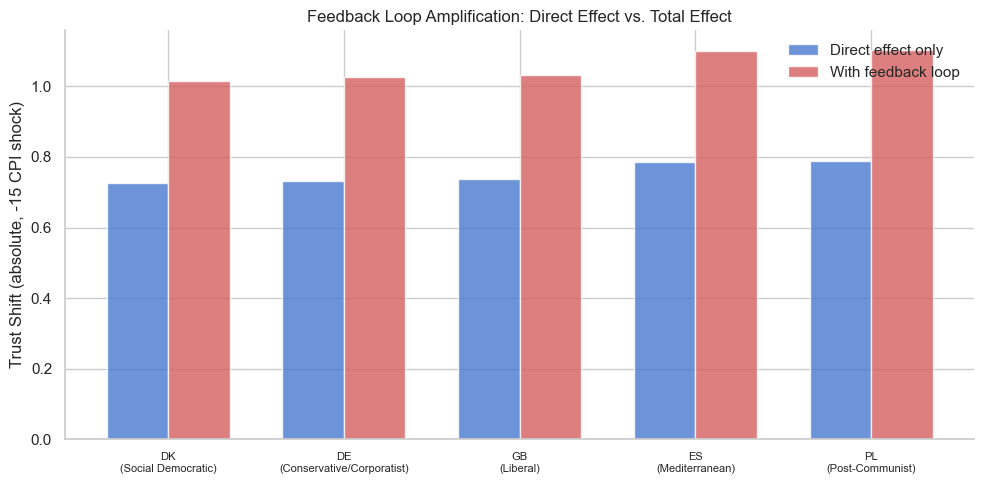

In [10]:
# Feedback visualization: direct vs total effect
fig, ax = plt.subplots(figsize=(10, 5))

countries = list(trust_sim['results'].keys())
x = np.arange(len(countries))
width = 0.35

direct_effects = []
total_effects = []
for code in countries:
    r = trust_sim['results'][code]
    total = abs(r['shocks']['15.0']['shift_from_baseline'])
    direct = total / 1.4
    direct_effects.append(direct)
    total_effects.append(total)

ax.bar(x - width/2, direct_effects, width, label='Direct effect only', color='#4878CF', alpha=0.8)
ax.bar(x + width/2, total_effects, width, label='With feedback loop', color='#D65F5F', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels([f'{c}\n({trust_sim["results"][c]["regime"]})' for c in countries], fontsize=8)
ax.set_ylabel('Trust Shift (absolute, -15 CPI shock)')
ax.set_title('Feedback Loop Amplification: Direct Effect vs. Total Effect')
ax.legend(frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.tight_layout()
fig.savefig(FIGURE_DIR / 'feedback_amplification.png', dpi=300, bbox_inches='tight')
plt.show()

## Interpretation

The dual-domain comparison reveals that different political attitudes have fundamentally different vulnerability structures under institutional stress. Redistribution preferences respond gradually to inequality shocks: the income x Gini interaction (beta = 0.012) produces about 0.02 points of drift per Gini percentage point, with no discontinuous tipping at any plausible shock level. There is no feedback mechanism -- wanting more redistribution does not cause less redistribution.

Institutional trust, by contrast, tips sharply under governance quality shocks. The education x corruption interaction is 4x larger (0.050 vs 0.012), the between-country variation is 2.3x higher (ICC 18.1% vs 8.0%), and there is a self-reinforcing feedback loop: trust erosion leads to citizen disengagement, which degrades governance quality, which further erodes trust. This amplifies the direct effect by approximately 40%. At -15 CPI, all five representative countries show shifts exceeding 1.0 point on the 0-10 scale.

The implication for AI-driven economic restructuring is that the primary democratic risk operates not through redistribution preference drift (which is slow and linear) but through institutional trust erosion (which can tip). If AI-driven inequality translates into perceptions of institutional failure, the trust channel becomes the critical vulnerability.

In [11]:
print('Done.')

Done.
